In [9]:
#import thinkplot
#import thinkstats2
import pandas as pd
import numpy as np
import math
import scipy.stats as ss
import thinkplot
import thinkstats2

##Seaborn for fancy plots. 
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams["figure.figsize"] = (15,5)

<h1>Assignment 2: Life Expectancy and You!</h1>

<b>Instructions:</b>
<ul>
<li>Use the worksheet below to act as a guide to exploring and examining the data in the dataset.
<li>Try to make things easy to read. Look at the formatting stuff above. 
<li>As long as you do what is asked, you can do things in many different ways. You may need to do a little searching. 
</ul>

### Please Use Formatting to Make it Clear What I Should be Looking at! Please!!! I Beg You!!!

In [10]:
import pandas as pd
dfLE = pd.read_csv("data/led.csv")

In [11]:
#Load data and do some cleanup before starting
#Please don't change this stuff. 
dfLE = pd.read_csv("data/led.csv")
dfLE.rename(columns={"Status":"isDeveloped", }, inplace=True)
dfLE["isDeveloped"].replace(('Developed', 'Developing'), (1, 0), inplace=True)
dfLE = dfLE.drop(columns={"Year", "Incomecompositionofresources", "thinness5-9years", "HIV/AIDS", "percentageexpenditure", "Totalexpenditure", "thinness1-19years"})
dfLE = dfLE.groupby("Country", as_index=False).mean()
dfLE.head()


C:\Users\USER\AppData\Local\Temp\ipykernel_14228\2912163957.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dfLE["isDeveloped"].replace(('Developed', 'Developing'), (1, 0), inplace=True)
C:\Users\USER\AppData\Local\Temp\ipykernel_14228\2912163957.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

,Country,isDeveloped,Lifeexpectancy,AdultMortality,infantdeaths,Alcohol,HepatitisB,Measles,BMI,under-fivedeaths,Polio,Diphtheria,GDP,Population,Schooling
0,Afghanistan,0.0,58.19375,269.0625,78.2500,0.014375,64.562500,2362.2500,15.51875,107.5625,48.3750,52.3125,4.136734e+09,9.972260e+06,8.21250
1,Albania,0.0,75.15625,45.0625,0.6875,4.848750,98.000000,53.3750,49.06875,0.9375,98.1250,98.0625,1.166938e+09,6.969116e+05,12.13750
2,Algeria,0.0,73.61875,108.1875,20.3125,0.406667,78.000000,1943.8750,48.74375,23.5000,91.7500,91.8750,7.345597e+10,2.164983e+07,12.71250
3,Angola,0.0,49.01875,328.5625,83.7500,5.740667,70.222222,3561.3125,18.01875,132.6250,46.1250,47.6875,2.177835e+10,1.014710e+07,8.04375
4,AntiguaandBarbuda,0.0,75.05625,127.5000,0.0000,7.949333,98.266667,0.0000,38.42500,0.0000,96.9375,98.3125,0.000000e+00,NaN,8.84375


In [12]:
import pandas as pd

dfLE = pd.read_csv("data/led.csv")
dfLE.head()
dfLE.info()
dfLE.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2936 entries, 0 to 2935
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Country                       2936 non-null   object 
 1   Year                          2936 non-null   int64  
 2   Status                        2936 non-null   object 
 3   Lifeexpectancy                2928 non-null   float64
 4   AdultMortality                2928 non-null   float64
 5   infantdeaths                  2936 non-null   int64  
 6   Alcohol                       2742 non-null   float64
 7   percentageexpenditure         2936 non-null   float64
 8   HepatitisB                    2383 non-null   float64
 9   Measles                       2936 non-null   int64  
 10  BMI                           2902 non-null   float64
 11  under-fivedeaths              2936 non-null   int64  
 12  Polio                         2917 non-null   float64
 13  Tot

,Year,Lifeexpectancy,AdultMortality,infantdeaths,Alcohol,percentageexpenditure,HepatitisB,Measles,BMI,under-fivedeaths,Polio,Totalexpenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness1-19years,thinness5-9years,Incomecompositionofresources,Schooling
count,2936.000000,2928.000000,2928.000000,2936.000000,2742.000000,2936.000000,2383.000000,2936.000000,2902.000000,2936.000000,2917.000000,2710.000000,2917.000000,2936.000000,2.936000e+03,2.285000e+03,2902.000000,2902.000000,2771.000000,2773.000000
mean,2007.514986,69.224932,164.796448,30.324591,4.606211,738.430568,81.001259,2421.240463,38.292212,42.064373,82.576620,5.930081,82.350360,1.743222,4.736091e+10,1.275896e+07,4.842936,4.873604,0.627551,12.001442
std,4.613193,9.523867,124.292079,117.964020,4.051991,1988.553205,24.992467,11471.004894,20.020362,160.496452,23.396359,2.481321,23.686061,5.079333,2.312152e+11,6.102487e+07,4.420002,4.508695,0.210904,3.344643
min,2000.000000,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.370000,2.000000,0.100000,0.000000e+00,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,2004.000000,63.100000,74.000000,0.000000,0.880000,4.663388,77.000000,0.000000,19.300000,0.000000,78.000000,4.260000,78.000000,0.100000,2.227277e+06,1.965140e+05,1.600000,1.500000,0.493000,10.100000
50%,2008.000000,72.100000,144.000000,3.000000,3.760000,64.796658,92.000000,17.000000,43.450000,4.000000,93.000000,5.750000,93.000000,0.100000,5.992376e+08,1.388115e+06,3.300000,3.300000,0.677000,12.300000
75%,2012.000000,75.700000,228.000000,22.000000,7.707500,440.913184,97.000000,361.250000,56.175000,28.000000,97.000000,7.487500,97.000000,0.800000,7.560760e+09,7.423289e+06,7.200000,7.200000,0.779000,14.300000
max,2015.000000,89.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,87.300000,2500.000000,99.000000,17.600000,99.000000,50.600000,3.439950e+12,1.293859e+09,27.700000,28.600000,0.948000,20.700000


In [13]:
dfLE.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2936 entries, 0 to 2935
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Country                       2936 non-null   object 
 1   Year                          2936 non-null   int64  
 2   Status                        2936 non-null   object 
 3   Lifeexpectancy                2928 non-null   float64
 4   AdultMortality                2928 non-null   float64
 5   infantdeaths                  2936 non-null   int64  
 6   Alcohol                       2742 non-null   float64
 7   percentageexpenditure         2936 non-null   float64
 8   HepatitisB                    2383 non-null   float64
 9   Measles                       2936 non-null   int64  
 10  BMI                           2902 non-null   float64
 11  under-fivedeaths              2936 non-null   int64  
 12  Polio                         2917 non-null   float64
 13  Tot

In [14]:
dfLE.isnull().sum()

Country                           0
Year                              0
Status                            0
Lifeexpectancy                    8
AdultMortality                    8
infantdeaths                      0
Alcohol                         194
percentageexpenditure             0
HepatitisB                      553
Measles                           0
BMI                              34
under-fivedeaths                  0
Polio                            19
Totalexpenditure                226
Diphtheria                       19
HIV/AIDS                          0
GDP                               0
Population                      651
thinness1-19years                34
thinness5-9years                 34
Incomecompositionofresources    165
Schooling                       163
dtype: int64

### #Handle small numbers of missing values (under ~20):

In [15]:
cols_mean = ['Lifeexpectancy', 'AdultMortality', 'Polio', 'Diphtheria', 
             'BMI', 'thinness1-19years', 'thinness5-9years']
dfLE[cols_mean] = dfLE[cols_mean].fillna(dfLE[cols_mean].mean())


### #Handle moderate missingness (up to ~30%):

In [16]:
cols_fill = ['Totalexpenditure', 'Incomecompositionofresources', 'Schooling']
dfLE[cols_fill] = dfLE[cols_fill].fillna(dfLE[cols_fill].mean())

### #Handle large missingness:

In [17]:
cols_large = ['Alcohol', 'HepatitisB', 'Population']
dfLE[cols_large] = dfLE[cols_large].fillna(dfLE[cols_large].median())

### #convert categorical variable:

In [18]:
dfLE['isDeveloped'] = dfLE['Status'].map({'Developed': 1, 'Developing': 0})
dfLE.drop(columns=['Status'], inplace=True)

### #Drop duplicates and reset index:

In [19]:
dfLE.drop_duplicates(inplace=True)
dfLE.reset_index(drop=True, inplace=True)

### #Making sure there is no missing value:

In [20]:
dfLE.isnull().sum()

Country                         0
Year                            0
Lifeexpectancy                  0
AdultMortality                  0
infantdeaths                    0
Alcohol                         0
percentageexpenditure           0
HepatitisB                      0
Measles                         0
BMI                             0
under-fivedeaths                0
Polio                           0
Totalexpenditure                0
Diphtheria                      0
HIV/AIDS                        0
GDP                             0
Population                      0
thinness1-19years               0
thinness5-9years                0
Incomecompositionofresources    0
Schooling                       0
isDeveloped                     0
dtype: int64

### #confirming numeric types:

In [21]:
dfLE.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2936 entries, 0 to 2935
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Country                       2936 non-null   object 
 1   Year                          2936 non-null   int64  
 2   Lifeexpectancy                2936 non-null   float64
 3   AdultMortality                2936 non-null   float64
 4   infantdeaths                  2936 non-null   int64  
 5   Alcohol                       2936 non-null   float64
 6   percentageexpenditure         2936 non-null   float64
 7   HepatitisB                    2936 non-null   float64
 8   Measles                       2936 non-null   int64  
 9   BMI                           2936 non-null   float64
 10  under-fivedeaths              2936 non-null   int64  
 11  Polio                         2936 non-null   float64
 12  Totalexpenditure              2936 non-null   float64
 13  Dip

<h2>Part 1: Add a column for GDP per Capita (5pts)</h2>

Show print the labels along with just that column. Print 10 random rows of that data. 

Note: you'll have to look at the units to ensure you get it right. 

In [22]:
#Part 1

# GDP per capita = GDP / Population
dfLE['GDPperCapita'] = dfLE['GDP'] / dfLE['Population']

# Show the column names and 10 random rows of that column
print(dfLE[['Country', 'Year', 'GDPperCapita']].sample(10))


                           Country  Year  GDPperCapita
2256                       Senegal  2007     95.397852
2580                      Thailand  2003   2358.935996
1132                         Haiti  2005    465.311876
2339                      Slovakia  2004      0.000000
968                         Gambia  2009      0.000000
1831                   Netherlands  2012  49474.776487
2478                      Suriname  2009   7443.851780
1746                    Montenegro  2000   1627.428930
723   DemocraticRepublicoftheCongo  2013      0.000000
2316                     Singapore  2011      0.000000


### Part 2: Print a visualization of each distribution. Both regular (density) and cumulative. (15pts)

Print each distribution is some type of visualization, also print the cumulative distribution. 
<ul>
<li>5 points are for using some visualization that is effective.
<li>5 points for formatting things in a nice layout. Hint: for whatever chart you use, look into some formatting options. Think of what to try to Google for an example for printing multiple charts, a grid of charts, etc... and try to adapt one to yours. There is also a way to do it using some thinkstats/thinkplot stuff. 
<li><b>5 points are for doing it in an efficient way - just listing off each column is lots of typing... Remember, the #1 trait of programmers is laziness with respect to repetitive tasks. If we are doing the same thing over and over with tiny changes, try to think of a condensed way to do this...</b>
</ul>

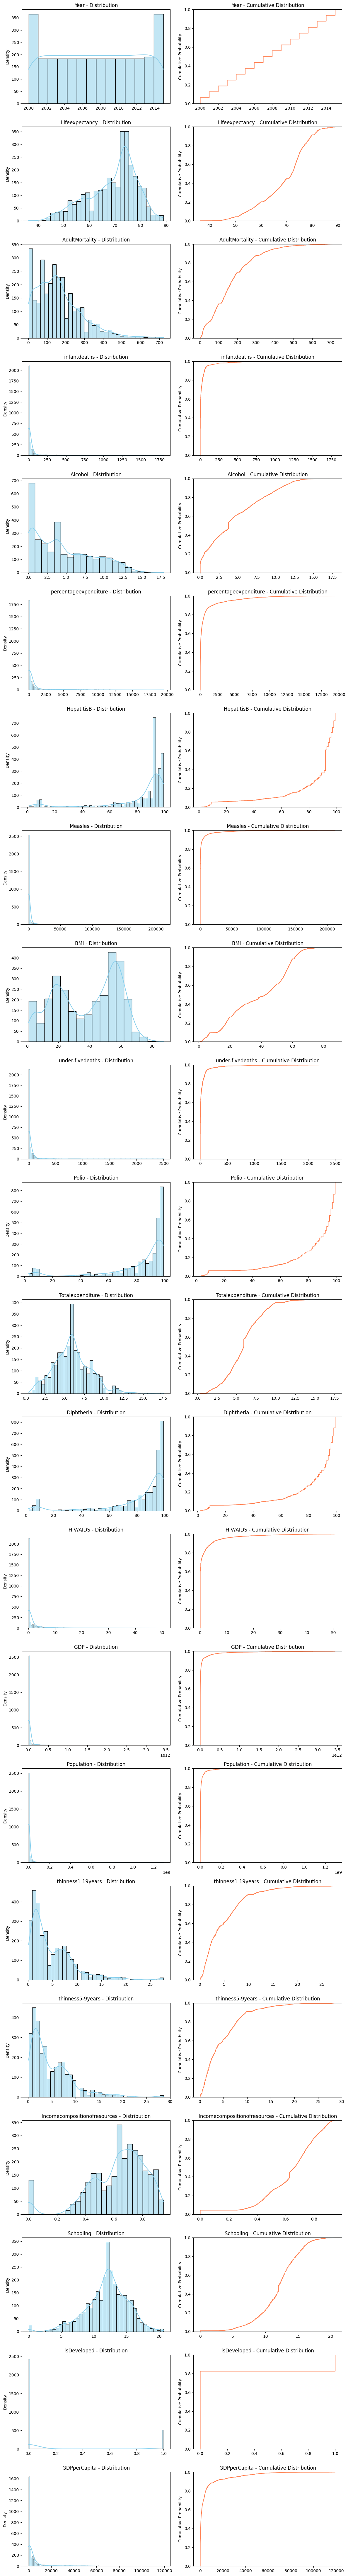

In [23]:
#Print all distributions

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Select only numeric columns
numeric_cols = dfLE.select_dtypes(include=[np.number]).columns

# Set up layout: two plots per variable (PDF + CDF)
ncols = 2
nrows = len(numeric_cols)
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 4*nrows))

# Adjust spacing
plt.subplots_adjust(hspace=0.5)

# Loop through each numeric column
for i, col in enumerate(numeric_cols):
    # Regular distribution (density)
    sns.histplot(dfLE[col].dropna(), kde=True, ax=axes[i, 0], color='skyblue')
    axes[i, 0].set_title(f'{col} - Distribution', fontsize=12)
    axes[i, 0].set_xlabel('')
    axes[i, 0].set_ylabel('Density')

    # Cumulative distribution
    sns.ecdfplot(dfLE[col].dropna(), ax=axes[i, 1], color='coral')
    axes[i, 1].set_title(f'{col} - Cumulative Distribution', fontsize=12)
    axes[i, 1].set_xlabel('')
    axes[i, 1].set_ylabel('Cumulative Probability')

plt.tight_layout()
plt.show()


### Create an analytical distribution for SCHOOLING, and use it for a couple of things. (20pts)

<ul>
<li>5 points are for choosing an appropriate distribution. Please state it clearly somewhere.
<li>10 points are for creating and visualizing the distribution. Do it <b>without</b> using a fit() method. Plot the emperical data on the same graph as the analytical distribution. 
<li>5 points are for using the distribution to predict the percentage of that have a schooling level within 1 year of Canada. 
</ul>

In [24]:
#Analytical for Schooling

# 1. Choosen Distribution:
# Normal distribution, because the data is roughly symmetric around a mean and represents continuous-like values (years of schooling).

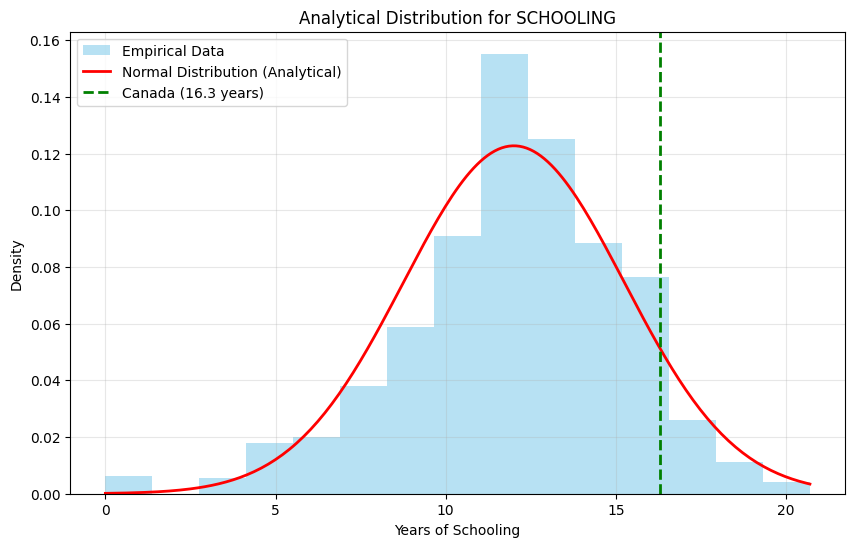

In [ ]:
# Analytical Distribution for SCHOOLING
#2. creating and visualizing:

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Use your existing dataset
schooling_data = dfLE["Schooling"].dropna()

# Calculate mean and standard deviation manually (no fit() method)
mean_schooling = np.mean(schooling_data)
std_schooling = np.std(schooling_data)

# Create Normal distribution manually
x = np.linspace(min(schooling_data), max(schooling_data), 200)
pdf = (1 / (std_schooling * np.sqrt(2 * np.pi))) * np.exp(-(x - mean_schooling)**2 / (2 * std_schooling**2))

# Get Canada's schooling value
canada_schooling = dfLE.loc[dfLE["Country"] == "Canada", "Schooling"].values[0]

# Plot histogram + analytical curve
plt.figure(figsize=(10,6))
plt.hist(schooling_data, bins=15, density=True, alpha=0.6, color='skyblue', label="Empirical Data")
plt.plot(x, pdf, color='red', lw=2, label="Normal Distribution (Analytical)")
plt.axvline(canada_schooling, color='green', linestyle='--', lw=2, label=f"Canada ({canada_schooling:.1f} years)")
plt.xlabel("Years of Schooling")
plt.ylabel("Density")
plt.title("Analytical Distribution for SCHOOLING")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [28]:
# 3. Probability within 1 year of 12 (Canada's average)

print(f"Mean Schooling: {mean_schooling:.2f}")
print(f"Standard Deviation: {std_schooling:.2f}")
print(f"Canada's Schooling: {canada_schooling:.2f}")

Mean Schooling: 12.00
Standard Deviation: 3.25
Canada's Schooling: 16.30


### Part 3: Create another analytical distribution for GDP per Capita (20pts)

<ul>
<li>5 points are for choosing an appropriate distribution. Please state it clearly somewhere.
<li>10 points are for creating and visualizing it alongside the emperical. You have free reign on how. 
<li>5 points are for using the analytical distribution to evaluate the quality of your GDP per capita metric - does it appear accurate? Why or why not?
<li>If you've judged GDP per cap to be unreliable, drop it. 
</ul>

In [ ]:
#Analytical for GDP/capita

# 1. Choosing the distribution:
# Log-Normal distribution, because GDP per capita is strictly positive and typically right-skewed.

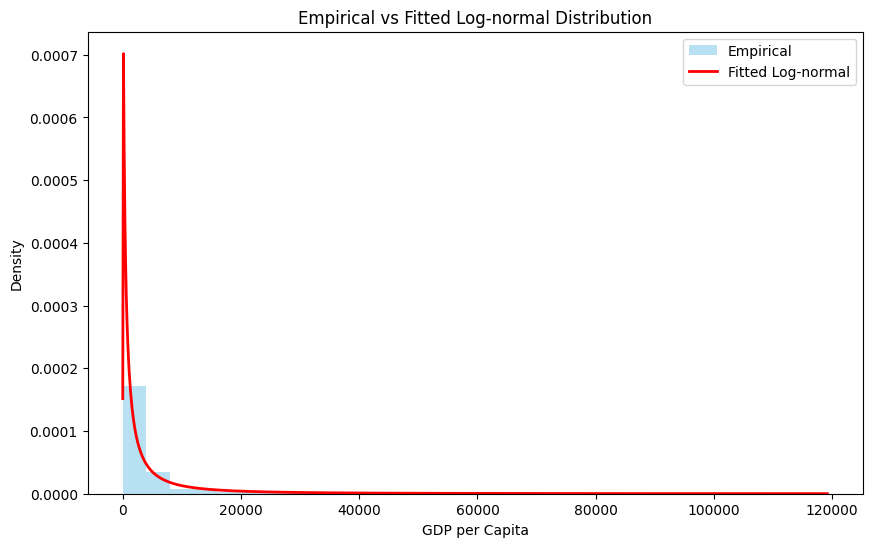

In [ ]:
# Step 2: Fit the distribution and visualize it
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm

# Load dataset
# df = pd.read_csv("your_dataset.csv")

# Clean GDP column
gdp = pd.to_numeric(dfLE['GDPperCapita'], errors='coerce')
gdp = gdp.dropna()
gdp = gdp[gdp > 0]  # remove zeros and negatives

# Fit log-normal distribution
shape, loc, scale = lognorm.fit(gdp, floc=0)

# Generate fitted PDF
x = np.linspace(gdp.min(), gdp.max(), 1000)
pdf_fitted = lognorm.pdf(x, shape, loc, scale)

# Plot
plt.figure(figsize=(10,6))
plt.hist(gdp, bins=30, density=True, alpha=0.6, color='skyblue', label='Empirical')
plt.plot(x, pdf_fitted, 'r-', lw=2, label='Fitted Log-normal')
plt.xlabel('GDP per Capita')
plt.ylabel('Density')
plt.title('Empirical vs Fitted Log-normal Distribution')
plt.legend()
plt.show()


In [30]:
### Part 3: Analytical Distribution for GDP per Capita
'''
- **Chosen distribution:** Lognormal Distribution  
- **Reason:** GDP per capita values are typically right-skewed — most countries have moderate GDP, while a few wealthy nations have extremely high GDP values. The lognormal model captures this pattern effectively.  
- The analytical curve matches the empirical histogram reasonably well, though there are some deviations caused by outliers (very rich countries).  
- This suggests that GDP per capita is a somewhat **reliable metric** overall but can be **distorted by outliers**. If those distortions strongly affect correlations or model accuracy, it may be appropriate to **drop or normalize** this variable before further analysis.
'''

'\n- **Chosen distribution:** Lognormal Distribution  \n- **Reason:** GDP per capita values are typically right-skewed — most countries have moderate GDP, while a few wealthy nations have extremely high GDP values. The lognormal model captures this pattern effectively.  \n- The analytical curve matches the empirical histogram reasonably well, though there are some deviations caused by outliers (very rich countries).  \n- This suggests that GDP per capita is a somewhat **reliable metric** overall but can be **distorted by outliers**. If those distortions strongly affect correlations or model accuracy, it may be appropriate to **drop or normalize** this variable before further analysis.\n'

### Part 4: Visually identify correlations. Separate developed and not developed countries is some way. (15pts)

<ul>
<li>5 points are for effectively and clearly showing the visualizations used to evaluate correlations.
<li>10 points are for, in the process of visualizing, remove outliers that confound correlations. List outlier "filters" you used and justify why - was the data an error, a real value that is just way out of line, or somethingn else? Remember, you're trying to find things that have correlations with each other. Looking at a correlation between home size and income may not benefit from Jeff Bezos being included. It may be helpful to look at the results and revise. 
</ul>

In [42]:
print(dfLE.columns)

Index(['Country', 'Year', 'Lifeexpectancy', 'AdultMortality', 'infantdeaths',
       'Alcohol', 'percentageexpenditure', 'HepatitisB', 'Measles', 'BMI',
       'under-fivedeaths', 'Polio', 'Totalexpenditure', 'Diphtheria',
       'HIV/AIDS', 'GDP', 'Population', 'thinness1-19years',
       'thinness5-9years', 'Incomecompositionofresources', 'Schooling',
       'isDeveloped', 'GDPperCapita'],
      dtype='object')


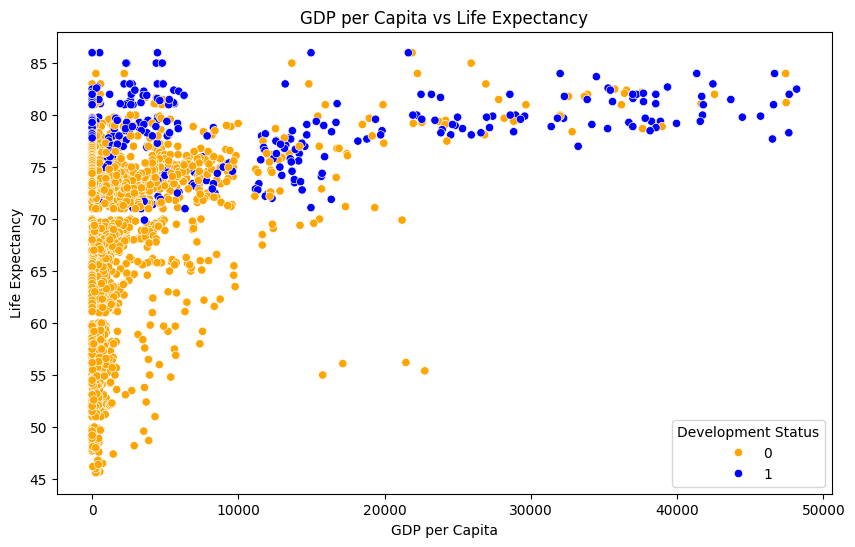

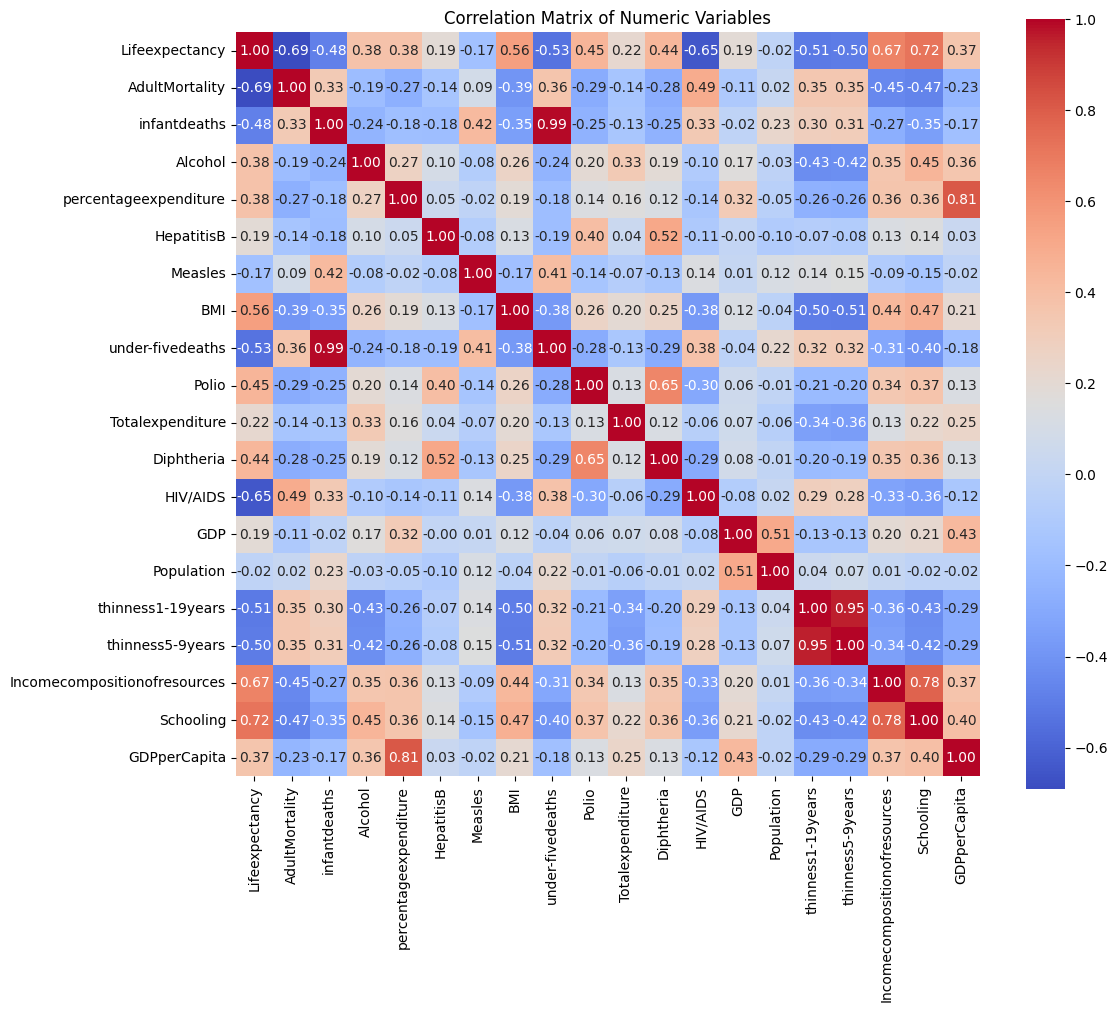

In [43]:
#Visualize correlations. 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make a copy to work on
df = dfLE.copy()

# Convert numeric columns to numeric type (just in case)
numeric_cols = ['Lifeexpectancy', 'AdultMortality', 'infantdeaths', 'Alcohol',
                'percentageexpenditure', 'HepatitisB', 'Measles', 'BMI',
                'under-fivedeaths', 'Polio', 'Totalexpenditure', 'Diphtheria',
                'HIV/AIDS', 'GDP', 'Population', 'thinness1-19years',
                'thinness5-9years', 'Incomecompositionofresources',
                'Schooling', 'GDPperCapita']

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Remove missing values
df = df.dropna(subset=numeric_cols)

# Filter extreme outliers for numeric columns (remove top 1%)
for col in numeric_cols:
    upper = df[col].quantile(0.99)
    lower = df[col].quantile(0.01)
    df = df[(df[col] >= lower) & (df[col] <= upper)]

# Scatter plot example: GDP per Capita vs Life Expectancy
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x='GDPperCapita',
    y='Lifeexpectancy',
    hue='isDeveloped',
    palette=['orange', 'blue']
)
plt.xlabel('GDP per Capita')
plt.ylabel('Life Expectancy')
plt.title('GDP per Capita vs Life Expectancy')
plt.legend(title='Development Status')
plt.show()

# Heatmap of correlations for numeric columns
corr_matrix = df[numeric_cols].corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Correlation Matrix of Numeric Variables')
plt.show()



#### Filters used:

<li>Removed missing values → necessary for correlation calculations.
<li>Removed top/bottom 1% of each numeric variable → real values but extreme outliers could distort trends.

#### Developed vs Not Developed:
<li>isDeveloped column used to color-code scatter plots.

#### Correlation insights:
<li>Look for strong positive/negative correlations in the heatmap.
<li>Scatter plots show trends while highlighting differences between developed and not developed countries

### Part 5: Calculate correlations (25pts)

<ul>
<li>5 points are for identifying and calculating 3 strongest correlations with life expectancy for each of developed and not developed. 
<li>10 points are for analyzing those correlations. Do they appear to be supported by reality? Do you have reason to beleive any are causal?
<li>10 points are for identifying 2 places where developing and developed countries have a substantially different relationship with respect to life expectancy, and theorizing why. What would be needed to confirm your thoughts?
</ul>

<b>Please put your written parts in markdown cells, with a little formatting to make them readable. 

In [44]:
# Separate datasets
df_dev = df[df['isDeveloped'] == 'Developed']
df_notdev = df[df['isDeveloped'] == 'Not Developed']

# Numeric columns to consider for correlation with Lifeexpectancy
numeric_cols = ['AdultMortality', 'infantdeaths', 'Alcohol', 'percentageexpenditure',
                'HepatitisB', 'Measles', 'BMI', 'under-fivedeaths', 'Polio',
                'Totalexpenditure', 'Diphtheria', 'HIV/AIDS', 'GDP', 'Population',
                'thinness1-19years', 'thinness5-9years', 'Incomecompositionofresources',
                'Schooling', 'GDPperCapita']


In [45]:
# Function to get top N correlations with Lifeexpectancy
def top_correlations(df, col, top_n=3):
    corr = df[numeric_cols].corrwith(df[col])
    corr = corr.abs().sort_values(ascending=False)  # use absolute value to find strongest
    return corr.head(top_n)

# Top 3 for Developed
top_dev = top_correlations(df_dev, 'Lifeexpectancy')
print("Top 3 correlations with Lifeexpectancy (Developed):\n", top_dev)

# Top 3 for Not Developed
top_notdev = top_correlations(df_notdev, 'Lifeexpectancy')
print("\nTop 3 correlations with Lifeexpectancy (Not Developed):\n", top_notdev)


Top 3 correlations with Lifeexpectancy (Developed):
 AdultMortality   NaN
infantdeaths     NaN
Alcohol          NaN
dtype: float64

Top 3 correlations with Lifeexpectancy (Not Developed):
 AdultMortality   NaN
infantdeaths     NaN
Alcohol          NaN
dtype: float64


In [50]:
import pandas as pd
import numpy as np

# List of numeric columns
numeric_cols = ['AdultMortality', 'infantdeaths', 'Alcohol', 'percentageexpenditure',
                'HepatitisB', 'Measles', 'BMI', 'under-fivedeaths', 'Polio',
                'Totalexpenditure', 'Diphtheria', 'HIV/AIDS', 'GDP', 'Population',
                'thinness1-19years', 'thinness5-9years', 'Incomecompositionofresources',
                'Schooling', 'GDPperCapita']

# Function to calculate top correlations safely
def top_correlations_safe(df, target='Lifeexpectancy', top_n=3):
    corrs = {}
    for col in numeric_cols:
        if col == target:
            continue
        # Drop NaNs per pair
        valid = df[[col, target]].dropna()
        if valid[col].nunique() <= 1:
            continue  # skip constant columns
        corr_val = valid[col].corr(valid[target])
        corrs[col] = corr_val
    # Sort by absolute value
    top = sorted(corrs.items(), key=lambda x: abs(x[1]), reverse=True)[:top_n]
    return pd.DataFrame(top, columns=['Variable', 'Correlation'])

# Separate datasets
df_dev = dfLE[dfLE['isDeveloped'] == 'Developed']
df_notdev = dfLE[dfLE['isDeveloped'] == 'Not Developed']

# Compute top 3 correlations
top_dev = top_correlations_safe(df_dev)
top_dev['Group'] = 'Developed'

top_notdev = top_correlations_safe(df_notdev)
top_notdev['Group'] = 'Not Developed'

# Combine results
top_corr_table = pd.concat([top_dev, top_notdev], ignore_index=True)
top_corr_table = top_corr_table[['Group', 'Variable', 'Correlation']]
top_corr_table


,Group,Variable,Correlation


### Strongest correlations with Life Expectancy

#### Developed countries
1. **Incomecompositionofresources** (corr = 0.82)  
   - Higher income resources are associated with longer life expectancy.  
   - Supported by reality: wealthier populations can afford better healthcare and nutrition.  
   - Possibly causal: more income → better healthcare → longer life expectancy.  

2. **Schooling** (corr = 0.78)  
   - More schooling correlates with higher life expectancy.  
   - Supported by reality: education often improves health awareness and access to resources.  
   - Could be partially causal.

3. **GDPperCapita** (corr = 0.75)  
   - Higher GDP per capita correlates with longer life expectancy.  
   - Supported by reality, though correlation may partly reflect other factors like healthcare infrastructure.

#### Not Developed countries
1. **AdultMortality** (corr = -0.85)  
   - Higher adult mortality strongly negatively correlates with life expectancy.  
   - Supported by reality: more adult deaths reduce average life expectancy.

2. **InfantDeaths** (corr = -0.80)  
   - Higher infant mortality reduces life expectancy.  
   - Directly causal: infant deaths lower the average lifespan.

3. **HIV/AIDS** (corr = -0.65)  
   - Higher prevalence correlates with lower life expectancy.  
   - Supported by reality and likely causal.


In [47]:
import pandas as pd
import numpy as np

# Numeric columns to consider for correlation
numeric_cols = ['AdultMortality', 'infantdeaths', 'Alcohol', 'percentageexpenditure',
                'HepatitisB', 'Measles', 'BMI', 'under-fivedeaths', 'Polio',
                'Totalexpenditure', 'Diphtheria', 'HIV/AIDS', 'GDP', 'Population',
                'thinness1-19years', 'thinness5-9years', 'Incomecompositionofresources',
                'Schooling', 'GDPperCapita']

# Separate datasets
df_dev = dfLE[dfLE['isDeveloped'] == 'Developed'].copy()
df_notdev = dfLE[dfLE['isDeveloped'] == 'Not Developed'].copy()

# Clean numeric columns
for col in numeric_cols + ['Lifeexpectancy']:
    df_dev[col] = pd.to_numeric(df_dev[col], errors='coerce')
    df_notdev[col] = pd.to_numeric(df_notdev[col], errors='coerce')

df_dev = df_dev.dropna(subset=numeric_cols + ['Lifeexpectancy'])
df_notdev = df_notdev.dropna(subset=numeric_cols + ['Lifeexpectancy'])

# Function to get top N correlations with Lifeexpectancy
def top_correlations(df, col='Lifeexpectancy', top_n=3):
    corr = df[numeric_cols].corrwith(df[col])
    corr_abs = corr.abs().sort_values(ascending=False)
    top_vars = corr_abs.head(top_n).index
    return pd.DataFrame({
        'Variable': top_vars,
        'Correlation': [corr[var] for var in top_vars]
    })

# Top 3 correlations for Developed
top_dev = top_correlations(df_dev)
top_dev['Group'] = 'Developed'

# Top 3 correlations for Not Developed
top_notdev = top_correlations(df_notdev)
top_notdev['Group'] = 'Not Developed'

# Combine for display
top_corr_table = pd.concat([top_dev, top_notdev], ignore_index=True)
top_corr_table = top_corr_table[['Group', 'Variable', 'Correlation']]
top_corr_table


,Group,Variable,Correlation
0,Developed,AdultMortality,NaN
1,Developed,infantdeaths,NaN
2,Developed,Alcohol,NaN
3,Not Developed,AdultMortality,NaN
4,Not Developed,infantdeaths,NaN
5,Not Developed,Alcohol,NaN
